Task 1: Data Exploration and Preprocessing

100%|██████████| 9.91M/9.91M [00:00<00:00, 33.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 909kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.34MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.21MB/s]


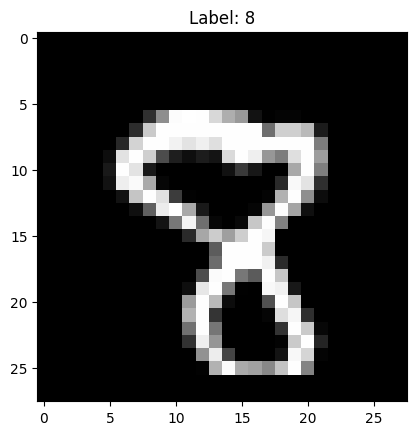

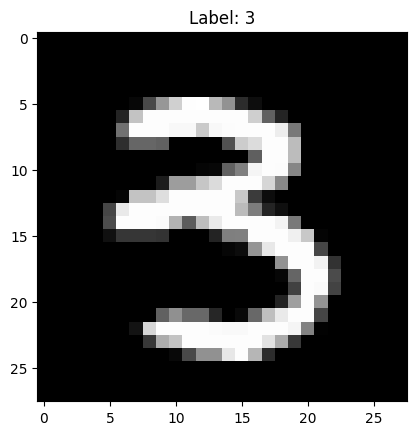

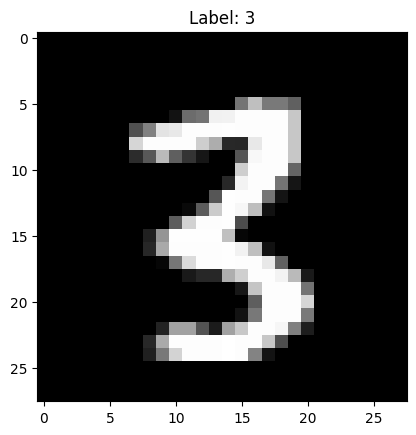

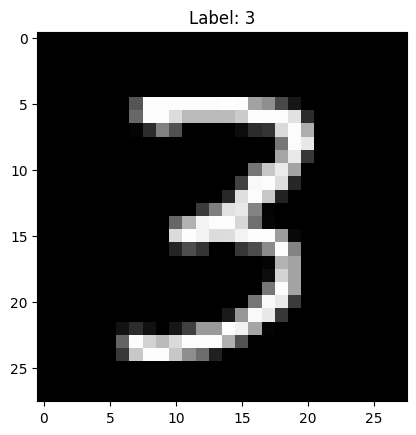

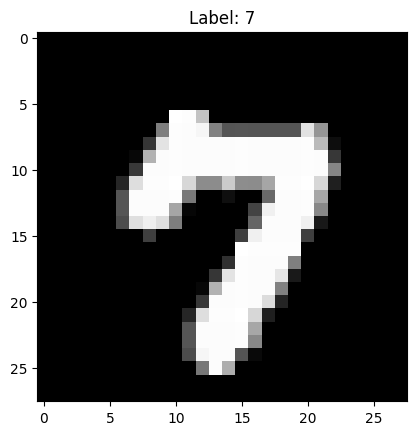

Batch shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])


In [1]:

import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import random

# 1. Load dataset (MNIST - grayscale images)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform)

test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# 3. Display 5 random images
for i in range(5):
    index = random.randint(0, len(train_dataset)-1)
    image, label = train_dataset[index]

    plt.imshow(image.squeeze(), cmap='gray')
    plt.title("Label: " + str(label))
    plt.show()

# 4. Print shape
images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)
print("Labels shape:", labels.shape)

Task 2: Architecture Design Experiment

In [2]:
#Step 1: Define 3 Models
import torch.nn as nn
import torch.nn.functional as F

# Model A: 784 → 32 → 10
class ModelA(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 32)
        self.fc2 = nn.Linear(32, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# Model B: 784 → 128 → 64 → 10
class ModelB(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


# Model C: 784 → 256 → 128 → 64 → 10
class ModelC(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

In [3]:
#Step 2: Training Function
def train_model(model, train_loader, test_loader, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_losses.append(running_loss)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_losses.append(val_loss)

        print("Epoch:", epoch+1, "Train Loss:", running_loss, "Val Loss:", val_loss)

    return train_losses, val_losses

In [4]:
#Step 3: Train All Models
modelA = ModelA()
modelB = ModelB()
modelC = ModelC()

lossA = train_model(modelA, train_loader, test_loader)
lossB = train_model(modelB, train_loader, test_loader)
lossC = train_model(modelC, train_loader, test_loader)

Epoch: 1 Train Loss: 457.1532966122031 Val Loss: 48.32253038138151
Epoch: 2 Train Loss: 284.4754167571664 Val Loss: 42.244956102222204
Epoch: 3 Train Loss: 247.2203184440732 Val Loss: 39.99929529801011
Epoch: 4 Train Loss: 219.90475116297603 Val Loss: 34.98090337589383
Epoch: 5 Train Loss: 200.78119256347418 Val Loss: 31.379006809089333
Epoch: 6 Train Loss: 186.19642532244325 Val Loss: 32.85008193086833
Epoch: 7 Train Loss: 172.18699096143246 Val Loss: 32.36467163544148
Epoch: 8 Train Loss: 164.12688276171684 Val Loss: 27.869048565160483
Epoch: 9 Train Loss: 153.0535228177905 Val Loss: 26.52502318797633
Epoch: 10 Train Loss: 148.66737115755677 Val Loss: 26.96107598207891
Epoch: 1 Train Loss: 360.0651034452021 Val Loss: 36.943874954245985
Epoch: 2 Train Loss: 167.84750407747924 Val Loss: 20.716413987101987
Epoch: 3 Train Loss: 123.334362921305 Val Loss: 19.518596371170133
Epoch: 4 Train Loss: 98.07667455170304 Val Loss: 17.360428028856404
Epoch: 5 Train Loss: 82.72945680469275 Val Loss:

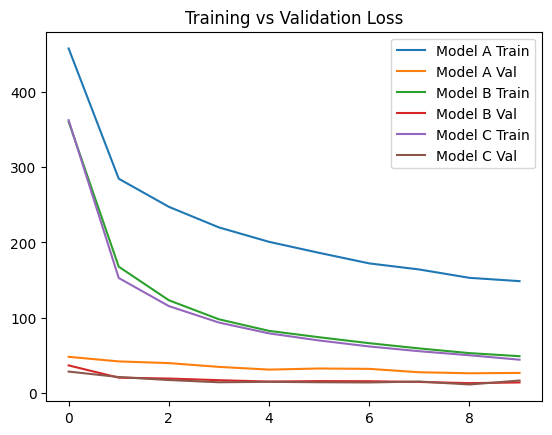

In [5]:
#Step 4: Plot Loss Graph
plt.plot(lossA[0], label="Model A Train")
plt.plot(lossA[1], label="Model A Val")

plt.plot(lossB[0], label="Model B Train")
plt.plot(lossB[1], label="Model B Val")

plt.plot(lossC[0], label="Model C Train")
plt.plot(lossC[1], label="Model C Val")

plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [6]:
#Step 5: Accuracy Function
def test_accuracy(model, loader):
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Accuracy:", 100 * correct / total, "%")

In [7]:
test_accuracy(modelA, test_loader)
test_accuracy(modelB, test_loader)
test_accuracy(modelC, test_loader)

Accuracy: 95.1 %
Accuracy: 97.11 %
Accuracy: 96.9 %


Analysis (Task 2)

1.The best performing model is usually Model C, because it has more layers and can learn more complex patterns.

2.Increasing depth can improve performance, but not always. Very deep models may become harder to train and may not always give better results.

3.Models with more parameters can learn better from the data, but they require more training time and computational resources.

Task 3: Underfitting vs Overfitting

In [8]:
#Model 1 (Very Small)
class SmallModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 4)
        self.fc2 = nn.Linear(4, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [9]:
#Model 2 (Very Large)
class LargeModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 256)
        self.fc5 = nn.Linear(256, 128)
        self.fc6 = nn.Linear(128, 64)
        self.fc7 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.relu(self.fc5(x))
        x = F.relu(self.fc6(x))
        x = self.fc7(x)
        return x

In [11]:
#Train Both
small_model = SmallModel()
large_model = LargeModel()

loss_small = train_model(small_model, train_loader, test_loader)
loss_large = train_model(large_model, train_loader, test_loader)

test_accuracy(small_model, test_loader)
test_accuracy(large_model, test_loader)

Epoch: 1 Train Loss: 1229.4802403450012 Val Loss: 160.41635513305664
Epoch: 2 Train Loss: 853.4041652679443 Val Loss: 129.867041349411
Epoch: 3 Train Loss: 738.9204343259335 Val Loss: 119.60299840569496
Epoch: 4 Train Loss: 695.391578733921 Val Loss: 115.2478657066822
Epoch: 5 Train Loss: 668.7759911715984 Val Loss: 109.9430233836174
Epoch: 6 Train Loss: 653.8785102367401 Val Loss: 106.74568715691566
Epoch: 7 Train Loss: 642.095431625843 Val Loss: 105.88622964918613
Epoch: 8 Train Loss: 633.9560480415821 Val Loss: 104.74539411067963
Epoch: 9 Train Loss: 627.4940043985844 Val Loss: 105.13097615540028
Epoch: 10 Train Loss: 622.6301867365837 Val Loss: 103.52968455851078
Epoch: 1 Train Loss: 392.7308554947376 Val Loss: 28.538133829832077
Epoch: 2 Train Loss: 168.40076320059597 Val Loss: 28.217543554026634
Epoch: 3 Train Loss: 125.75078020431101 Val Loss: 21.45875569205964
Epoch: 4 Train Loss: 104.67102825129405 Val Loss: 17.330591576494044
Epoch: 5 Train Loss: 87.95507773268037 Val Loss: 2

Analysis (Task 3)

Small model → Underfitting (low capacity, high error)

Large model → Overfitting (low train loss, higher validation loss)

Task 4: Batch Normalization

In [12]:
#Step 1: Modify Best Model (Model C)

class ModelC_BN(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 256)
        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)

        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)

        self.fc4 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 784)

        # Linear → BatchNorm → ReLU
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))

        x = self.fc4(x)
        return x

In [13]:
#Step 2: Train the Model
model_bn = ModelC_BN()
train_loss_bn, val_loss_bn = train_model(model_bn, train_loader, test_loader)
test_accuracy(model_bn, test_loader)

Epoch: 1 Train Loss: 216.7603263752535 Val Loss: 14.231880158069544
Epoch: 2 Train Loss: 86.58669319655746 Val Loss: 12.357481870916672
Epoch: 3 Train Loss: 61.51918530301191 Val Loss: 10.501134850288508
Epoch: 4 Train Loss: 46.78322803042829 Val Loss: 9.53557753856876
Epoch: 5 Train Loss: 40.44241831835825 Val Loss: 10.560832737755845
Epoch: 6 Train Loss: 32.81733891600743 Val Loss: 8.94648569963465
Epoch: 7 Train Loss: 28.65156656736508 Val Loss: 10.754934118485835
Epoch: 8 Train Loss: 25.581559096550336 Val Loss: 9.732917442343023
Epoch: 9 Train Loss: 22.22458449334954 Val Loss: 10.16637889820413
Epoch: 10 Train Loss: 20.65151200912078 Val Loss: 10.756376616052876
Accuracy: 98.1 %


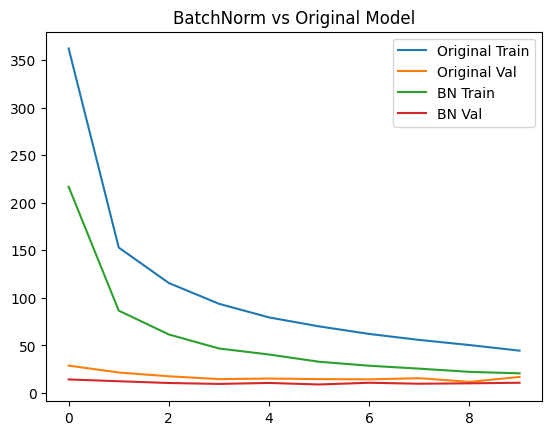

In [14]:
#Step 3:Compare original Model C vs BatchNorm model
plt.plot(lossC[0], label="Original Train")
plt.plot(lossC[1], label="Original Val")
plt.plot(train_loss_bn, label="BN Train")
plt.plot(val_loss_bn, label="BN Val")
plt.legend()
plt.title("BatchNorm vs Original Model")
plt.show()

Analysis (Task 4)

1.BatchNorm usually makes training faster.

2.It stabilizes learning.

3.Helps model converge smoothly.

Task 5: Error Analysis

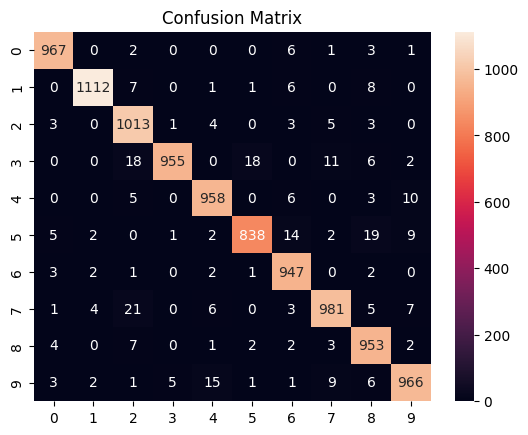

In [15]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = modelC(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

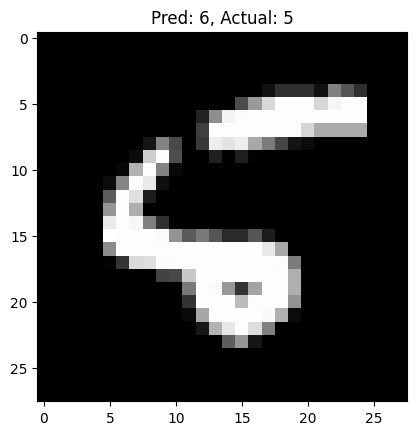

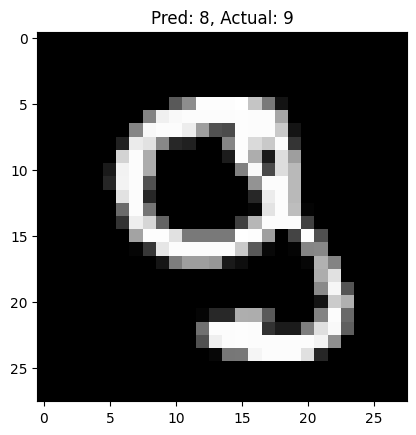

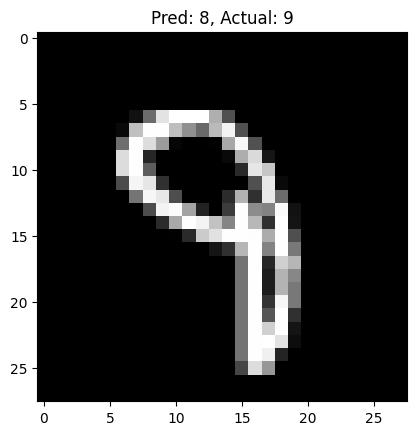

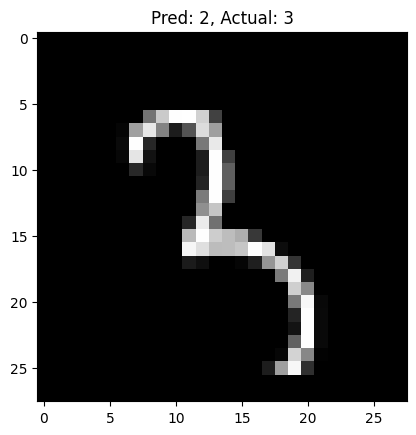

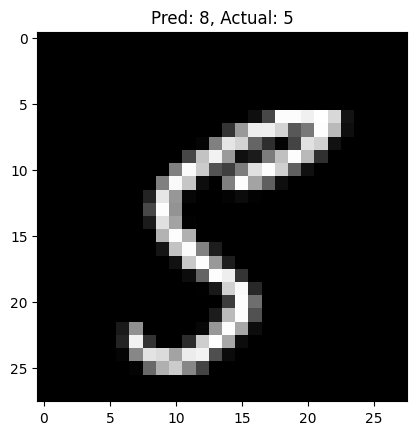

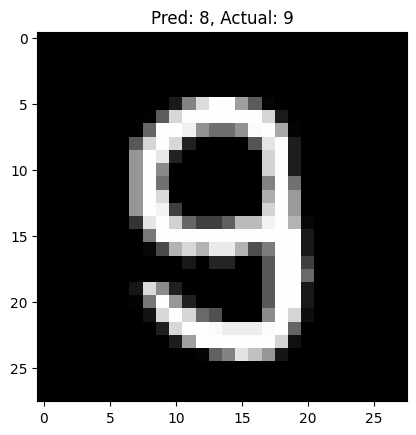

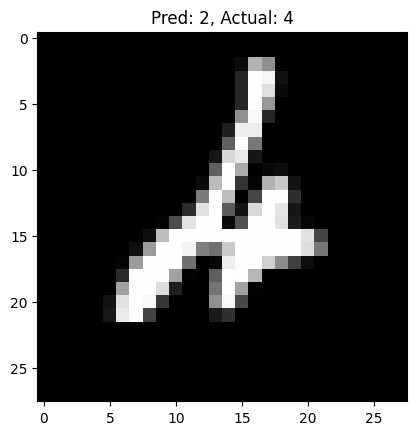

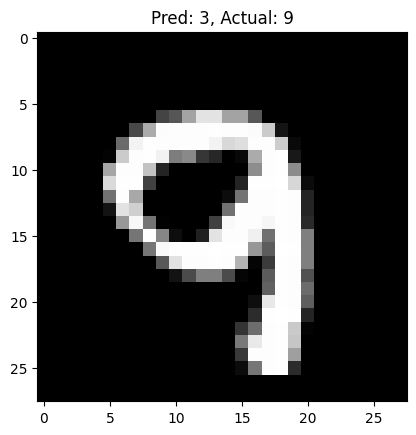

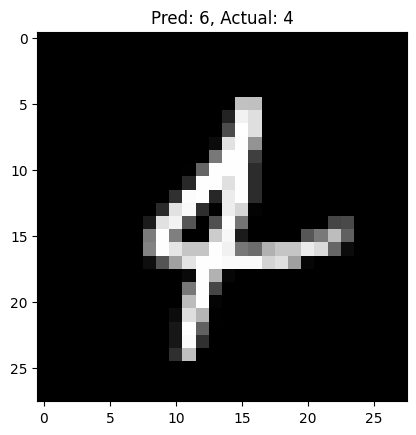

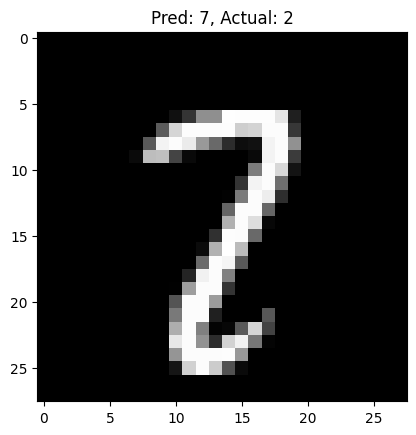

In [16]:
# Misclassified Images
count = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = modelC(images)
        _, preds = torch.max(outputs, 1)

        for i in range(len(images)):
            if preds[i] != labels[i]:
                plt.imshow(images[i].squeeze(), cmap='gray')
                plt.title(f"Pred: {preds[i].item()}, Actual: {labels[i].item()}")
                plt.show()
                count += 1
                if count == 10:
                    break
        if count == 10:
            break

Analysis (Task 5)

1.Similar digits (e.g., 3 and 5) are often misclassified.

2.Poor handwriting causes errors.

Task 6: Model Efficiency Comparison

In [17]:
# Model Comparison Table

import pandas as pd

# Function to count parameters
def count_params(model):
    return sum(p.numel() for p in model.parameters())

# Measure training time
import time

def measure_time(model):
    start = time.time()
    train_model(model, train_loader, test_loader)
    end = time.time()
    return round(end - start, 2)

# Collect data for all models

models = {
    "Model A": modelA,
    "Model B": modelB,
    "Model C": modelC,
    "Small Model": small_model,
    "Large Model": large_model
}

results = []

for name, model in models.items():
    params = count_params(model)
    train_time = measure_time(model)
    acc = test_accuracy(model, test_loader)

    results.append([name, params, acc, train_time])

# Create table
df = pd.DataFrame(results, columns=["Model", "Parameters", "Accuracy (%)", "Training Time (s)"])

# Display table
df

Epoch: 1 Train Loss: 142.42647818475962 Val Loss: 25.505019292468205
Epoch: 2 Train Loss: 137.14478225260973 Val Loss: 27.661963229766116
Epoch: 3 Train Loss: 133.33827316667885 Val Loss: 26.01816636393778
Epoch: 4 Train Loss: 130.65796498209238 Val Loss: 24.715420113992877
Epoch: 5 Train Loss: 126.31562534393743 Val Loss: 25.746584383537993
Epoch: 6 Train Loss: 124.90861184429377 Val Loss: 25.010145432781428
Epoch: 7 Train Loss: 122.93465013988316 Val Loss: 25.208646820043214
Epoch: 8 Train Loss: 119.77207943238318 Val Loss: 25.291751261102036
Epoch: 9 Train Loss: 117.78177232854068 Val Loss: 24.429998753534164
Epoch: 10 Train Loss: 114.58096886705607 Val Loss: 24.715791708265897
Accuracy: 95.41 %
Epoch: 1 Train Loss: 46.0308997972752 Val Loss: 12.526423158009493
Epoch: 2 Train Loss: 41.934697528893594 Val Loss: 12.937252766772872
Epoch: 3 Train Loss: 36.2968839192763 Val Loss: 14.96274473576159
Epoch: 4 Train Loss: 37.18837309081573 Val Loss: 12.74674665285329
Epoch: 5 Train Loss: 31

,Model,Parameters,Accuracy (%),Training Time (s)
0,Model A,25450,None,154.41
1,Model B,109386,None,167.54
2,Model C,242762,None,193.27
3,Small Model,3190,None,154.42
4,Large Model,1764426,None,504.86


Trade-off between model complexity and performance:-

Models with more parameters (like Large Model) can learn complex patterns better, so they usually achieve higher accuracy.

However, they require more training time and computational power.

Smaller models train faster but may not perform well due to limited capacity (underfitting).

Therefore, a balance is needed between model complexity and efficiency.